In [2]:
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr

matplotlib.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                             "axes.spines.right": False})
plt.rcParams["font.size"] = 9

In [3]:
df   = pd.read_parquet("features.parquet")
shap = pd.read_csv("results/shap_importance.csv")

META      = {"essay_id", "prompt_name", "level", "score"}
feat_cols = [c for c in df.columns if c not in META]

LEVEL_NAMES     = {0: "Original", 1: "Light", 2: "Medium", 3: "Heavy"}
LEVEL_SHORT     = {0: "Orig", 1: "L", 2: "M", 3: "H"}
FRAGILITY_COLORS = {"fragile": "#d62728", "robust": "#2ca02c", "neutral": "#7f7f7f"}
FRAGILITY_ORDER  = ["fragile", "neutral", "robust"]

# Convenience look-ups keyed by feature name
frag_map  = shap.set_index("feature_name")["fragility_label"].to_dict()
shap_map  = shap.set_index("feature_name")["mean_shap_overall"].to_dict()

print(f"{'Level':<10} {'Name':<12} {'N essays':>10}")
for lv, name in LEVEL_NAMES.items():
    n = (df["level"] == lv).sum()
    print(f"{lv:<10} {name:<12} {n:>10,}")
print(f"\nFeature columns : {len(feat_cols)}")
print(f"Unique essays    : {df['essay_id'].nunique():,}")
print(f"Unique prompts   : {df['prompt_name'].nunique():,}")

Level      Name           N essays
0          Original         24,728
1          Light            24,728
2          Medium           24,728
3          Heavy            24,728

Feature columns : 26
Unique essays    : 24,728
Unique prompts   : 7


In [4]:
# Score distribution per level
score_dist = (
    df.groupby("level")["score"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)
score_dist["level_name"] = score_dist["level"].map(LEVEL_NAMES)

pivot = score_dist.pivot(index="level_name", columns="score", values="proportion").fillna(0)
print("Score proportions per level  (all levels share identical score distributions,")
print("confirming essays are paired correctly):")
print(pivot.round(3).to_string())

Score proportions per level  (all levels share identical score distributions,
confirming essays are paired correctly):
score         1.0    2.0    3.0    4.0    5.0    6.0
level_name                                          
Heavy       0.071  0.277  0.365  0.225  0.055  0.008
Light       0.071  0.277  0.365  0.225  0.055  0.008
Medium      0.071  0.277  0.365  0.225  0.055  0.008
Original    0.071  0.277  0.365  0.225  0.055  0.008


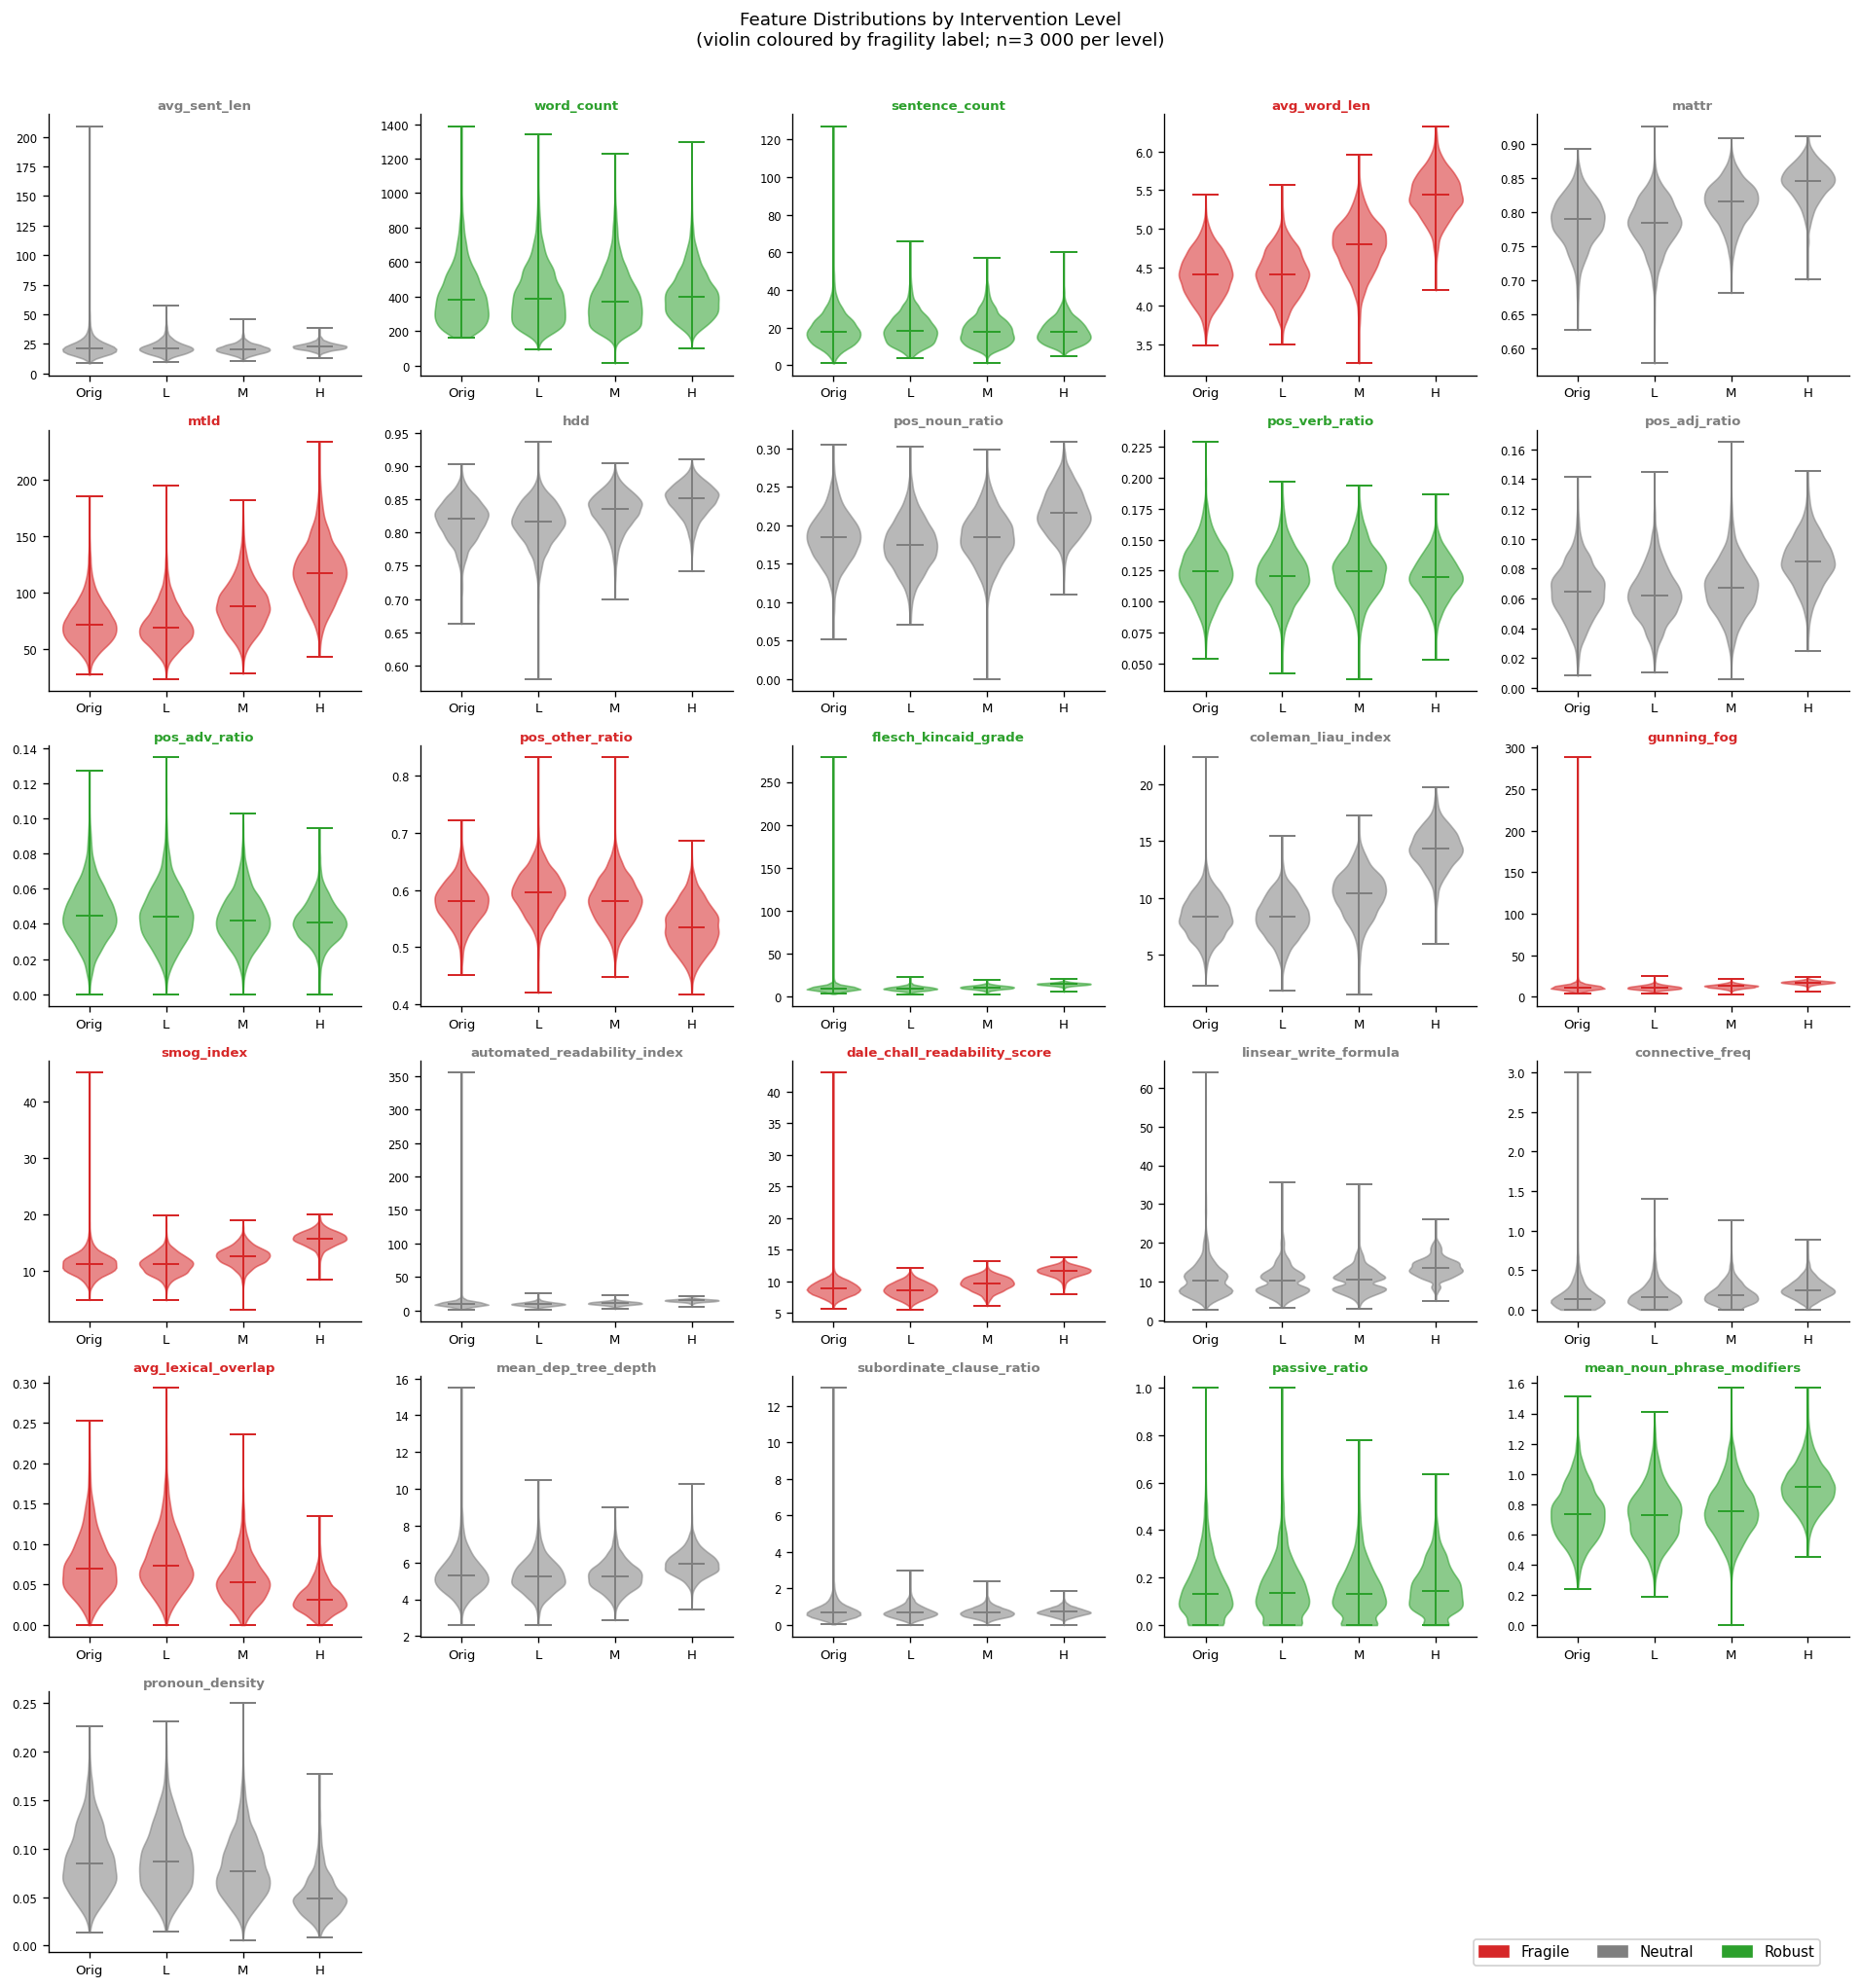

In [5]:
# Random sample for KDE speed — set seed for reproducibility
rng  = np.random.default_rng(42)
N_SAMPLE = 3_000
sample_idx = {
    lv: rng.choice(np.where(df["level"] == lv)[0], size=N_SAMPLE, replace=False)
    for lv in [0, 1, 2, 3]
}

ncols = 5
nrows = math.ceil(len(feat_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.8))

for i, feat in enumerate(feat_cols):
    ax     = axes.flat[i]
    color  = FRAGILITY_COLORS[frag_map[feat]]
    data   = [df.iloc[sample_idx[lv]][feat].dropna().values for lv in [0, 1, 2, 3]]

    parts = ax.violinplot(data, positions=[0, 1, 2, 3], showmedians=True,
                          widths=0.7)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
        pc.set_edgecolor(color)
    for part in ("cbars", "cmins", "cmaxes", "cmedians"):
        if part in parts:
            parts[part].set_color(color)
            parts[part].set_linewidth(1.2)

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([LEVEL_SHORT[l] for l in [0, 1, 2, 3]], fontsize=8)
    ax.set_title(feat, fontsize=8, color=color, fontweight="bold", pad=3)
    ax.tick_params(axis="y", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

for j in range(i + 1, nrows * ncols):
    axes.flat[j].set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color=FRAGILITY_COLORS[lbl],
                   label=f"{lbl.capitalize()}")
    for lbl in FRAGILITY_ORDER
]
fig.legend(handles=legend_handles, loc="lower right", ncol=3,
           fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.98, 0.01))

fig.suptitle("Feature Distributions by Intervention Level\n"
             "(violin coloured by fragility label; n=3 000 per level)",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig("results/feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

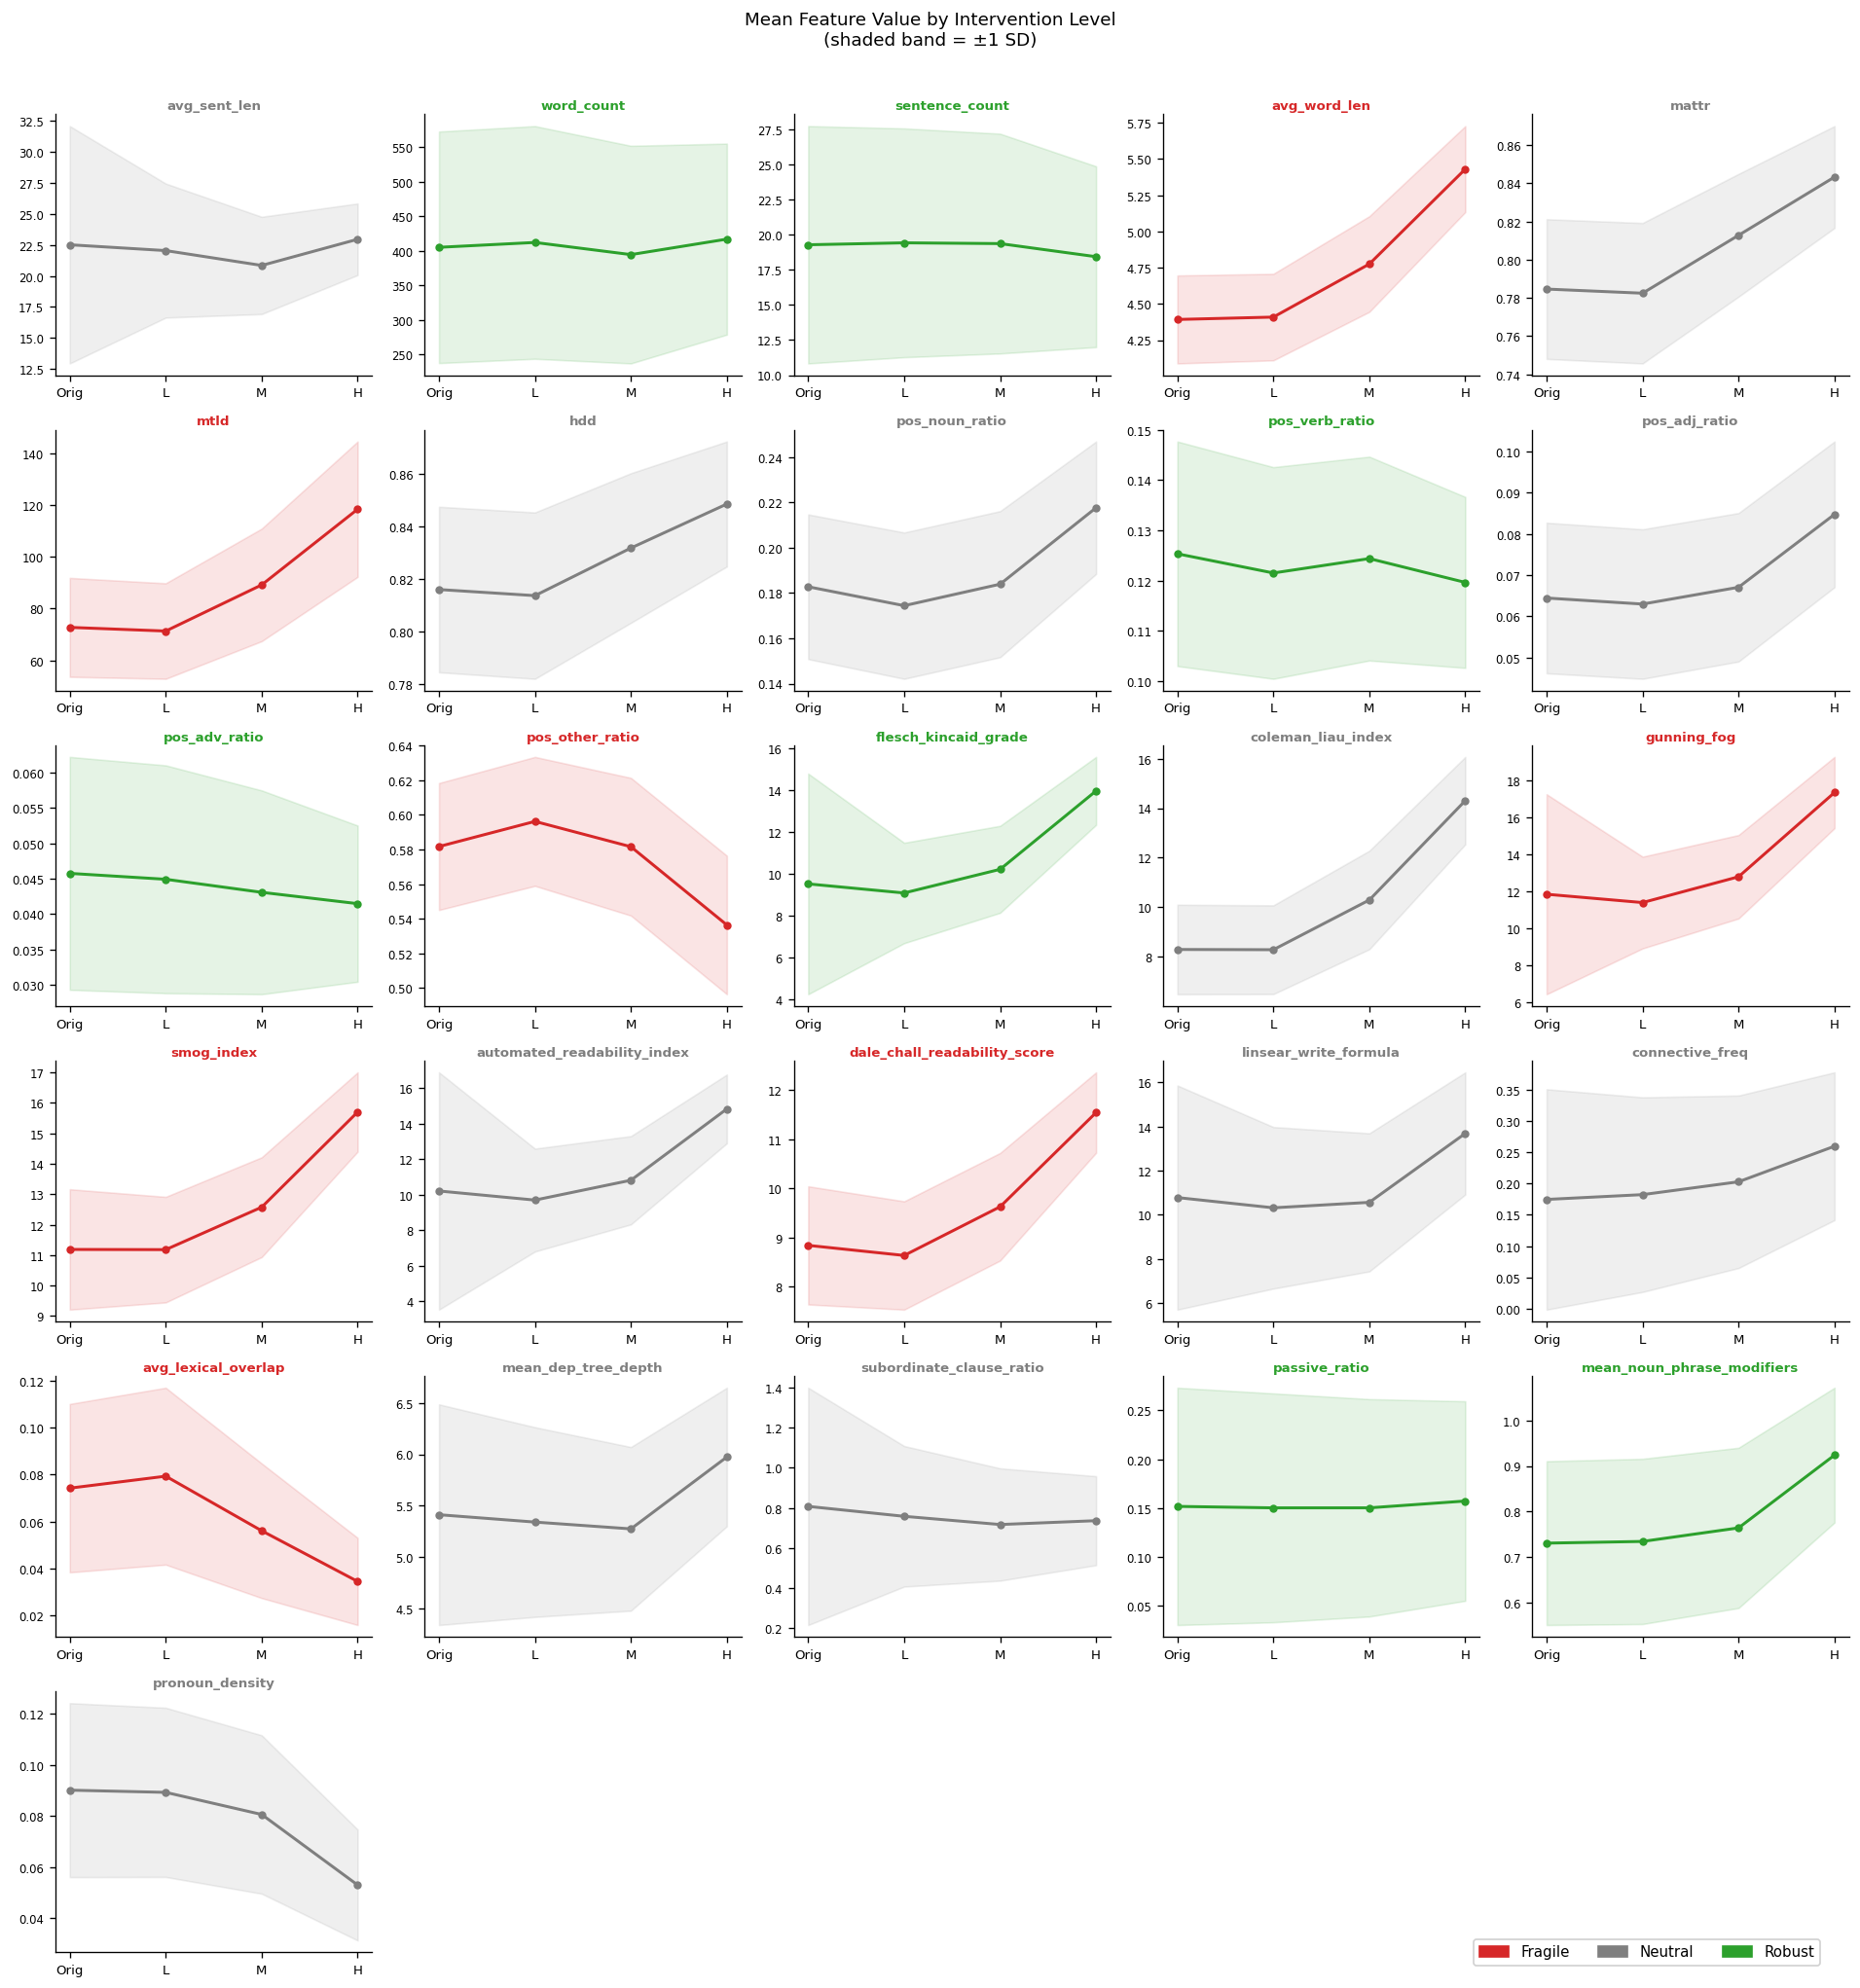

In [7]:
means = df.groupby("level")[feat_cols].mean()
stds  = df.groupby("level")[feat_cols].std()

ncols = 5
nrows = math.ceil(len(feat_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.8))
levels = [0, 1, 2, 3]

for i, feat in enumerate(feat_cols):
    ax    = axes.flat[i]
    color = FRAGILITY_COLORS[frag_map[feat]]
    m     = means[feat].values
    s     = stds[feat].values

    ax.plot(levels, m, color=color, linewidth=1.8, marker="o", markersize=4)
    ax.fill_between(levels, m - s, m + s, color=color, alpha=0.12)

    ax.set_xticks(levels)
    ax.set_xticklabels([LEVEL_SHORT[l] for l in levels], fontsize=8)
    ax.set_title(feat, fontsize=8, color=color, fontweight="bold", pad=3)
    ax.tick_params(axis="y", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

for j in range(i + 1, nrows * ncols):
    axes.flat[j].set_visible(False)

legend_handles = [
    mpatches.Patch(color=FRAGILITY_COLORS[lbl], label=lbl.capitalize())
    for lbl in FRAGILITY_ORDER
]
fig.legend(handles=legend_handles, loc="lower right", ncol=3,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.98, 0.01))

fig.suptitle("Mean Feature Value by Intervention Level\n"
             "(shaded band = ±1 SD)",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.savefig("results/feature_shift.png", dpi=120, bbox_inches="tight")
plt.show()

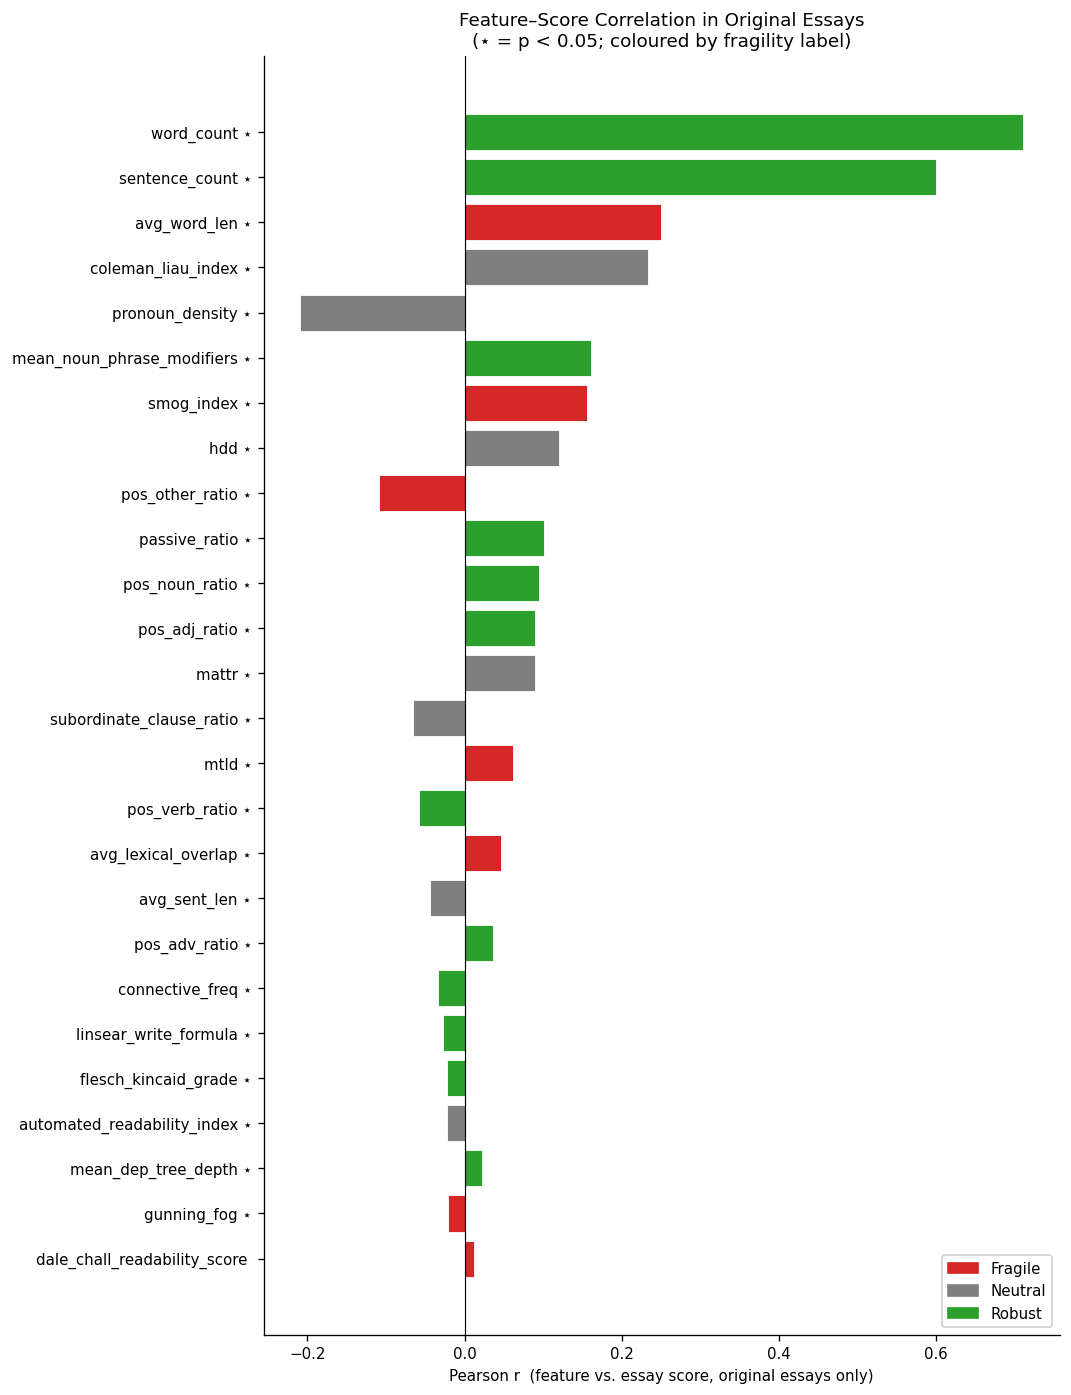


Pearson correlations sorted by |r|:
                feature_name  pearson_r  p_value fragility
                  word_count     0.7112   0.0000    robust
              sentence_count     0.6004   0.0000    robust
                avg_word_len     0.2496   0.0000   fragile
          coleman_liau_index     0.2330   0.0000   neutral
             pronoun_density    -0.2097   0.0000   neutral
  mean_noun_phrase_modifiers     0.1612   0.0000    robust
                  smog_index     0.1558   0.0000   fragile
                         hdd     0.1199   0.0000   neutral
             pos_other_ratio    -0.1086   0.0000   fragile
               passive_ratio     0.1008   0.0000    robust
              pos_noun_ratio     0.0951   0.0000    robust
               pos_adj_ratio     0.0898   0.0000    robust
                       mattr     0.0898   0.0000   neutral
    subordinate_clause_ratio    -0.0654   0.0000   neutral
                        mtld     0.0610   0.0000   fragile
              pos_v

In [11]:
orig = df[df["level"] == 0].copy()

corr_rows = []
for feat in feat_cols:
    valid = orig[["score", feat]].dropna()
    r, p  = pearsonr(valid[feat], valid["score"])
    corr_rows.append({
        "feature_name": feat,
        "pearson_r":    r,
        "p_value":      p,
        "fragility":    frag_map.get(feat, "neutral"),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r", key=abs, ascending=True)

colors = [FRAGILITY_COLORS[lbl] for lbl in corr_df["fragility"]]
labels = [
    f"{row['feature_name']} {'⋆' if row['p_value'] < 0.05 else ''}"
    for _, row in corr_df.iterrows()
]

fig_h = max(6, len(corr_df) * 0.45)
fig, ax = plt.subplots(figsize=(9, fig_h))

bars = ax.barh(labels, corr_df["pearson_r"], color=colors,
               edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Pearson r  (feature vs. essay score, original essays only)")
ax.set_title("Feature–Score Correlation in Original Essays\n"
             "(⋆ = p < 0.05; coloured by fragility label)", fontsize=11)

legend_handles = [
    mpatches.Patch(color=FRAGILITY_COLORS[lbl], label=lbl.capitalize())
    for lbl in FRAGILITY_ORDER
]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("results/score_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nPearson correlations sorted by |r|:")
print(
    corr_df[["feature_name","pearson_r","p_value","fragility"]]
    .sort_values("pearson_r", key=abs, ascending=False)
    .to_string(index=False, float_format="{:.4f}".format)
)